<a href="https://colab.research.google.com/github/srujith2006/neuralNetworking/blob/main/CNN_imgSeg.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install tensorflow opencv-python matplotlib numpy

In [2]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.layers import *
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

IMG_SIZE = 128

In [3]:
def create_mask(label_path, img_width, img_height):

    mask = np.zeros((img_height, img_width), dtype=np.uint8)

    if not os.path.exists(label_path):
        return mask

    with open(label_path, 'r') as f:
        lines = f.readlines()

    for line in lines:

        values = line.strip().split()

        class_id = int(values[0])

        polygon = np.array(values[1:], dtype=np.float32)

        polygon = polygon.reshape(-1, 2)

        polygon[:, 0] *= img_width
        polygon[:, 1] *= img_height

        polygon = polygon.astype(np.int32)

        cv2.fillPoly(mask, [polygon], 255)

    return mask


In [4]:
def load_dataset(image_dir, label_dir):

    images = []
    masks = []

    image_files = os.listdir(image_dir)

    for image_file in image_files:

        image_path = os.path.join(image_dir, image_file)

        label_file = image_file.rsplit('.', 1)[0] + ".txt"
        label_path = os.path.join(label_dir, label_file)

        image = cv2.imread(image_path)

        if image is None:
            continue

        image = cv2.resize(image, (IMG_SIZE, IMG_SIZE))

        h, w = IMG_SIZE, IMG_SIZE

        mask = create_mask(label_path, w, h)

        image = image / 255.0
        mask = mask / 255.0

        mask = np.expand_dims(mask, axis=-1)

        images.append(image)
        masks.append(mask)

    return np.array(images), np.array(masks)

In [11]:
train_images = "/content/train/images"
train_labels = "/content/train/labels"

X, y = load_dataset(train_images, train_labels)

print("Images:", X.shape)
print("Masks :", y.shape)

Images: (89, 128, 128, 3)
Masks : (89, 128, 128, 1)


In [10]:
import os

print("Contents of /content/:")
print(os.listdir('/content/'))

if os.path.exists('/content/dataset'):
    print("\nContents of /content/dataset/:")
    print(os.listdir('/content/dataset'))
else:
    print("\n/content/dataset does not exist.")

Contents of /content/:
['.config', 'test', 'dataset.zip', 'train', 'data.yaml', 'valid', 'README.dataset.txt', 'README.roboflow.txt', 'sample_data']

/content/dataset does not exist.


In [7]:
import zipfile

with zipfile.ZipFile('/content/dataset.zip', 'r') as zip_ref:
    zip_ref.extractall('/content/')

print("Dataset extracted successfully.")

Dataset extracted successfully.


In [12]:
inputs = Input((IMG_SIZE, IMG_SIZE, 3))

# Encoder
c1 = Conv2D(64, 3, activation='relu', padding='same')(inputs)
c1 = Conv2D(64, 3, activation='relu', padding='same')(c1)
p1 = MaxPooling2D()(c1)

c2 = Conv2D(128, 3, activation='relu', padding='same')(p1)
c2 = Conv2D(128, 3, activation='relu', padding='same')(c2)
p2 = MaxPooling2D()(c2)

# Bottleneck
b1 = Conv2D(256, 3, activation='relu', padding='same')(p2)
b1 = Conv2D(256, 3, activation='relu', padding='same')(b1)

# Decoder
u1 = UpSampling2D()(b1)
u1 = concatenate([u1, c2])

c3 = Conv2D(128, 3, activation='relu', padding='same')(u1)
c3 = Conv2D(128, 3, activation='relu', padding='same')(c3)

u2 = UpSampling2D()(c3)
u2 = concatenate([u2, c1])

c4 = Conv2D(64, 3, activation='relu', padding='same')(u2)
c4 = Conv2D(64, 3, activation='relu', padding='same')(c4)

outputs = Conv2D(1, 1, activation='sigmoid')(c4)

model = Model(inputs, outputs)

model.compile(
    optimizer=Adam(1e-4),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 128, 128,  │      1,792 │ input_layer[0][0] │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 128, 128,  │     36,928 │ conv2d[0][0]      │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 64, 64,    │          0 │ conv2d_1[0][0]    │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 64, 64,    │     73,856 │ max_pooling2d[0]… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 64, 64,    │    147,584 │ conv2d_2[0][0]    │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 32, 32,    │          0 │ conv2d_3[0][0]    │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 32, 32,    │    295,168 │ max_pooling2d_1[… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 32, 32,    │    590,080 │ conv2d_4[0][0]    │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ up_sampling2d       │ (None, 64, 64,    │          0 │ conv2d_5[0][0]    │
│ (UpSampling2D)      │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 64, 64,    │          0 │ up_sampling2d[0]… │
│ (Concatenate)       │ 384)              │            │ conv2d_3[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_6 (Conv2D)   │ (None, 64, 64,    │    442,496 │ concatenate[0][0] │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_7 (Conv2D)   │ (None, 64, 64,    │    147,584 │ conv2d_6[0][0]    │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ up_sampling2d_1     │ (None, 128, 128,  │          0 │ conv2d_7[0][0]    │
│ (UpSampling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_1       │ (None, 128, 128,  │          0 │ up_sampling2d_1[… │
│ (Concatenate)       │ 192)              │            │ conv2d_1[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_8 (Conv2D)   │ (None, 128, 128,  │    110,656 │ concatenate_1[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_9 (Conv2D)   │ (None, 128, 128,  │     36,928 │ conv2d_8[0][0]  

 Total params: 1,883,137 (7.18 MB)

 Trainable params: 1,883,137 (7.18 MB)

 Non-trainable params: 0 (0.00 B)

In [13]:
model.fit(
    X,
    y,
    epochs=10,
    batch_size=2,
    validation_split=0.1
)

Epoch 1/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 108s 3s/step - accuracy: 0.9668 - loss: 0.3050 - val_accuracy: 0.9682 - val_loss: 0.1818
Epoch 2/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 142s 3s/step - accuracy: 0.9676 - loss: 0.1935 - val_accuracy: 0.9682 - val_loss: 0.1807
Epoch 3/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 138s 2s/step - accuracy: 0.9676 - loss: 0.1647 - val_accuracy: 0.9682 - val_loss: 0.1443
Epoch 4/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 98s 2s/step - accuracy: 0.9676 - loss: 0.1544 - val_accuracy: 0.9682 - val_loss: 0.1374
Epoch 5/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 95s 2s/step - accuracy: 0.9676 - loss: 0.1772 - val_accuracy: 0.9682 - val_loss: 0.1631
Epoch 6/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 141s 2s/step - accuracy: 0.9676 - loss: 0.1469 - val_accuracy: 0.9682 - val_loss: 0.1292
Epoch 7/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 96s 2s/step - accuracy: 0.9676 - loss: 0.1440 - val_accuracy: 0.9682 - val_loss: 0.1290
Epoch 8/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 95s 2s/step - accuracy: 0.9676 - loss: 0.1410 - val_accuracy: 0.9682 - val_l

In [14]:
model.save("person_segmentation_model.h5")

print("Model Saved!")

Model Saved!


In [15]:
test_img_path = os.path.join(train_images, os.listdir(train_images)[0])

test_img = cv2.imread(test_img_path)

test_img_resized = cv2.resize(test_img, (IMG_SIZE, IMG_SIZE))

input_img = test_img_resized / 255.0
input_img = np.expand_dims(input_img, axis=0)

prediction = model.predict(input_img)[0]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 884ms/step


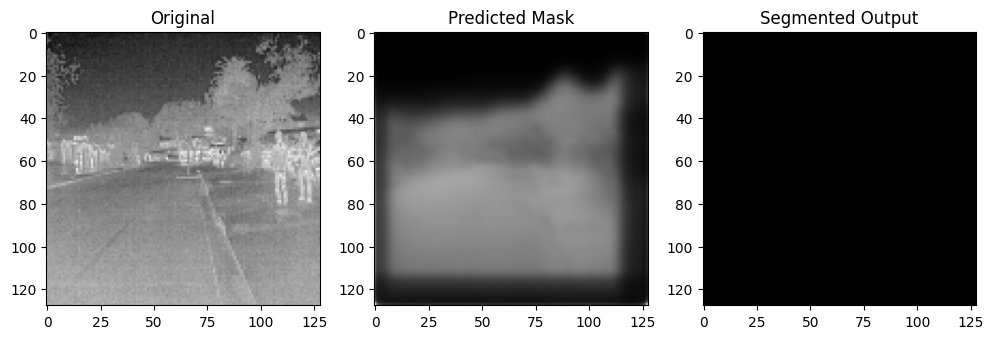

In [16]:
plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.title("Original")
plt.imshow(cv2.cvtColor(test_img_resized, cv2.COLOR_BGR2RGB))

plt.subplot(1,3,2)
plt.title("Predicted Mask")
plt.imshow(prediction[:,:,0], cmap='gray')

plt.subplot(1,3,3)
plt.title("Segmented Output")

segmented = test_img_resized.copy()

segmented[prediction[:,:,0] < 0.5] = 0

plt.imshow(cv2.cvtColor(segmented, cv2.COLOR_BGR2RGB))

plt.show()